# Processus Aléatoires (Ex 3.1)
M.Tognolini - feb. 2026 HEIG-VD rev 1.1 

# 1. Configuration de l'environnement

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
# Configuration pour des graphiques clairs
%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 6]

## 2. Génération du Processus Aléatoire

Un processus aléatoire $X(n,\zeta)$ est une famille de fonctions du temps indexées par un paramètre aléatoire $\zeta$. On génère ici $N_R$ réalisations de longueur $L$, stockées dans une matrice où chaque ligne est un instant temporel et chaque colonne une réalisation.

L'exemple classique est un processus sinusoïdal à **phase aléatoire** $\phi$ uniformément distribuée sur $[0, 2\pi]$ :

$$X(n) = A\cos(\omega_0 n + \phi)$$

> **Pourquoi une phase aléatoire ?**  
> C'est le paramètre $\phi$ qui introduit l'aléatoire : pour chaque réalisation, une valeur de $\phi$ est tirée indépendamment. L'amplitude $A$ et la fréquence $\omega_0$ sont fixes — seule la phase change d'une réalisation à l'autre.

**Propriété clé :** Ce processus est **stationnaire au sens large (WSS)** — sa moyenne et son autocorrélation ne dépendent pas de l'instant $n$ absolu, mais uniquement du lag $k$ :

$$m_X = \mathbb{E}[X(n)] = 0 \qquad r_X(k) = \frac{A^2}{2}\cos(\omega_0 k)$$

**Reproductibilité :** On fixe la graine du générateur aléatoire (`numpy.random.seed`) pour garantir que les mêmes réalisations sont générées à chaque exécution — indispensable pour comparer les résultats.

Forme de la matrice X : (100, 1000)
Les 5 premières valeurs de la réalisation 1 :
[-0.95333378 -0.90797605 -0.848299   -0.77524377 -0.68996248]


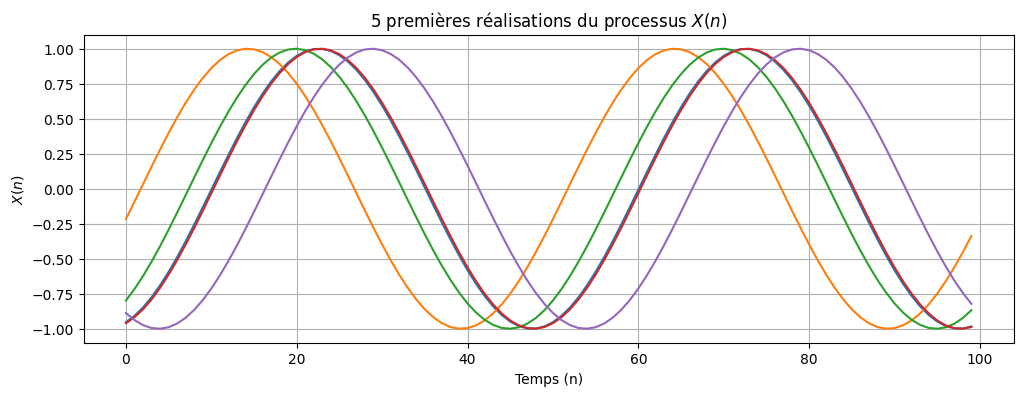

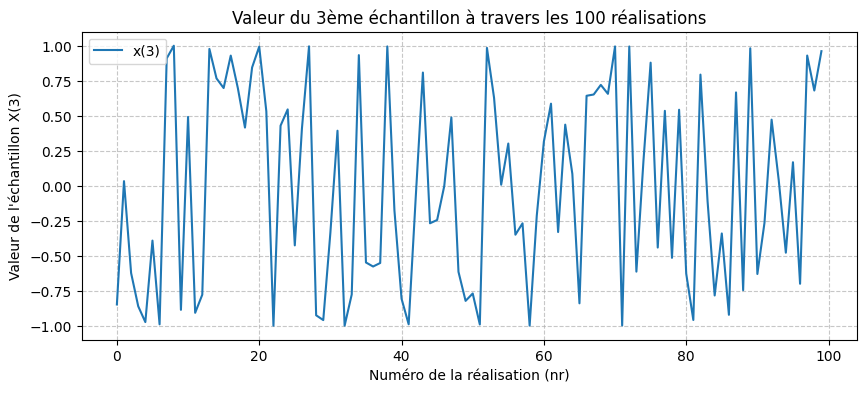

In [3]:
# Fixer la graine pour la reproductibilité
np.random.seed(0)

# Paramètres
NR = 100        # Nombre de réalisations
N = 1000        # Nombre d'échantillons
A = 1.0
F0 = 1/50       # Fréquence normalisée (cycles par échantillon)
omega0 = 2 * np.pi * F0
n = np.arange(N)
Anoise = 0.0

# Génération de la phase (une par réalisation)
phi = np.random.uniform(0, 2 * np.pi, size=(NR, 1))

# Création de la matrice des processus (NR x N)
X = A * np.cos(omega0 * n + phi)

# Ajout du bruit blanc gaussien
noise = Anoise * np.random.normal(0, 0.1, size=(NR, N))
X = X + noise

print(f"Forme de la matrice X : {X.shape}")
print("Les 5 premières valeurs de la réalisation 1 :")
print(X[0, :5])

# Affichage des 5 premières réalisations
plt.figure(figsize=(12, 4))
plt.plot(n[:100], X[:5, :100].T)
plt.title("5 premières réalisations du processus $X(n)$")
plt.xlabel("Temps (n)")
plt.ylabel("$X(n)$")
plt.grid(True)
plt.show()

# Extraction du 3ème échantillon pour toutes les réalisations
nr = np.arange(NR)
sample_3 = X[:, 2]

# Affichage du 3ème échantillon à travers les réalisations
plt.figure(figsize=(10, 4))
plt.plot(nr, sample_3, label='x(3)')
plt.title('Valeur du 3ème échantillon à travers les 100 réalisations')
plt.xlabel('Numéro de la réalisation (nr)')
plt.ylabel("Valeur de l'échantillon X(3)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 3. Statistiques d'Ensemble

La **moyenne d'ensemble** est calculée en faisant la moyenne de toutes les réalisations à chaque instant $n$ fixé :

$$\mu_x(n) = \mathbb{E}[X(n)] = \frac{1}{N_R} \sum_{i=1}^{N_R} X_i(n)$$

En pratique, cela correspond à faire la moyenne **colonne par colonne** de la matrice $X$ (de taille $N_R \times N$) — on obtient un vecteur de taille $N$.

> **Valeur théorique attendue :**  
> Pour notre processus $X(n) = A\cos(\omega_0 n + \phi)$ avec $\phi \sim \mathcal{U}[0, 2\pi]$ :
> $$\mu_x(n) = \mathbb{E}[A\cos(\omega_0 n + \phi)] = 0$$
> La moyenne est nulle pour tout $n$, car les phases aléatoires se compensent en moyenne. Si $N_R$ est suffisamment grand, la moyenne estimée doit converger vers 0. 

<>:17: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:17: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_124114/490564631.py:17: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.title("Variance d'ensemble $\sigma^2_X(n)$")


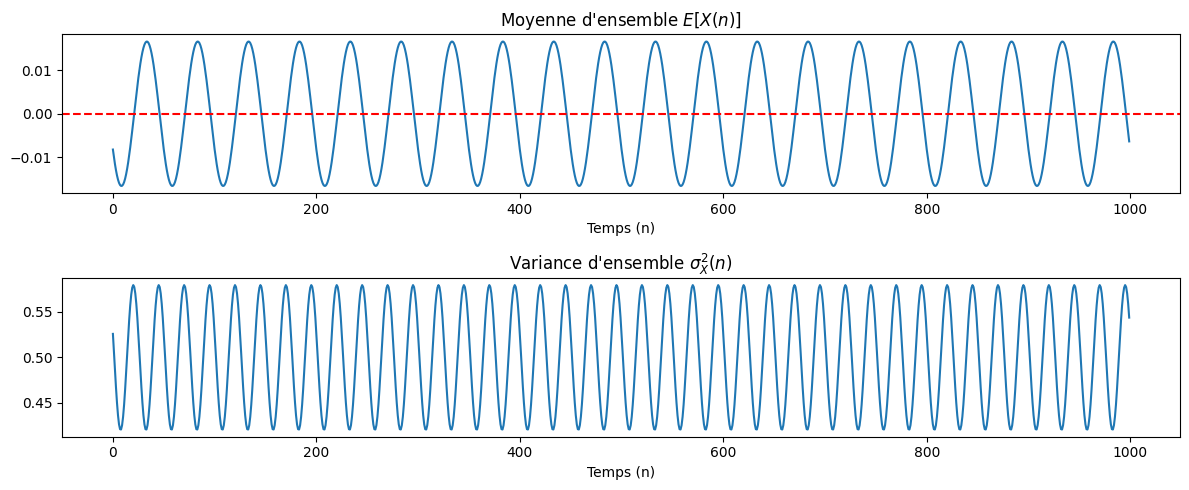

In [4]:
# Moyenne d'ensemble (axis=0 : moyenne sur les réalisations à chaque instant n)
ensemble_mean = np.mean(X, axis=0)

# Variance d'ensemble
ensemble_var = np.var(X, axis=0)

plt.figure(figsize=(12, 5))

plt.subplot(2, 1, 1)
plt.plot(n, ensemble_mean)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Moyenne d'ensemble $E[X(n)]$")
plt.xlabel("Temps (n)")

plt.subplot(2, 1, 2)
plt.plot(n, ensemble_var)
plt.title("Variance d'ensemble $\sigma^2_X(n)$")
plt.xlabel("Temps (n)")

plt.tight_layout()
plt.show()

### Constations

**Moyenne d'ensemble :** La moyenne est nulle pour tout $n$, car les phases aléatoires $\phi \sim \mathcal{U}[0, 2\pi]$ des différentes réalisations se compensent mutuellement en moyenne.

**Variance d'ensemble :** Elle est calculée à chaque instant $n$ sur l'ensemble des réalisations :

$$\sigma_x^2(n) = \mathbb{E}[(X(n) - \mu_x(n))^2] = \frac{1}{N_R} \sum_{i=1}^{N_R} (X_i(n) - \mu_x(n))^2$$

La variance est un vecteur de taille $N$. Sa valeur théorique pour notre processus est :

$$\sigma_x^2 = \frac{A^2}{2}$$

> **Pourquoi $A^2/2$ ?**  
> La puissance moyenne d'un cosinus d'amplitude $A$ est $A^2/2$, indépendamment de la phase. Comme $\mu_x = 0$, la variance est égale à la puissance du signal. Avec $A = 1$, on attend donc $\sigma_x^2 \approx 0.5$ — constant pour tout $n$, ce qui confirme la stationnarité du processus.

## 4. Moment du second ordre : Autocorrélation et Ergodicité

### Autocorrélation d'ensemble

L'autocorrélation $R_{XX}(n_1, n_2)$ mesure la dépendance statistique entre deux instants $n_1$ et $n_2$. Pour un processus **WSS (Wide-Sense Stationary)**, elle ne dépend que du lag $k = n_1 - n_2$ :

$$R_{XX}(k) = \mathbb{E}[X(n)X(n+k)]$$

Pour notre processus sinusoïdal à phase aléatoire uniforme, la valeur théorique est :

$$R_{XX}(k) = \frac{A^2}{2} \cos(2\pi f_0 k)$$

> **Interprétation :** L'autocorrélation est maximale en $k=0$ (valeur $A^2/2$ = variance), puis oscille en cosinus à la fréquence $f_0$ du signal. Elle ne dépend pas de $n$ — preuve de la stationnarité.

### Ergodicité

Un processus est dit **ergodique** si ses statistiques temporelles (calculées sur une seule réalisation longue) coïncident avec ses statistiques d'ensemble (calculées sur de nombreuses réalisations à un instant fixé).

> **En pratique :** Si le processus est ergodique, on peut estimer $R_{XX}(k)$ en calculant l'autocorrélation temporelle d'une seule réalisation, plutôt que de nécessiter un grand nombre de réalisations. Notre processus sinusoïdal à phase uniforme est ergodique au sens large — la moyenne temporelle et la moyenne d'ensemble convergent toutes deux vers 0, et les autocorrélations temporelle et d'ensemble coïncident.

Taille de la matrice Rx : (1000, 1000)
Exemple de valeurs dans Rx :
 [[0.52586697 0.51231586 0.49068522 0.46131619 0.42467192]
 [0.51231586 0.50639364 0.4924853  0.47081016 0.44171007]
 [0.49068522 0.4924853  0.48651858 0.47287918 0.45178219]
 [0.46131619 0.47081016 0.47287918 0.46749061 0.45472943]
 [0.42467192 0.44171007 0.45178219 0.45472943 0.45050532]]
r_x_estimate shape : (1999,)
Diagonale pour k=0 : [0.52586697 0.50639364 0.48651858 0.46749061 0.45050532]
Diagonale pour k=1 : [0.51231586 0.4924853  0.47287918 0.45472943 0.43917647]
Valeur moyenne de la diagonale k=1 : 0.4960222480670715


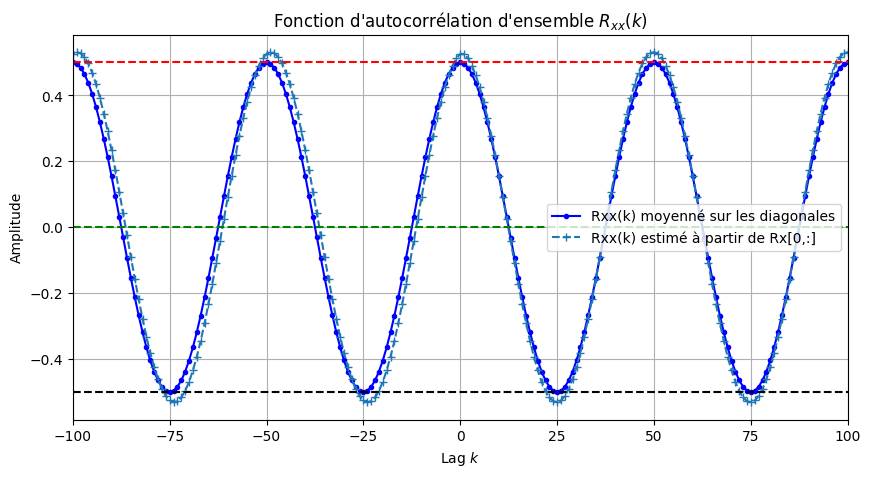

In [5]:
# Calcul de la matrice d'autocorrélation Rx (N x N)
Rx = (1 / NR) * (X.T @ X)

print(f"Taille de la matrice Rx : {Rx.shape}")
print(f"Exemple de valeurs dans Rx :\n {Rx[:5, :5]}")

# Extraction de la fonction d'autocorrélation depuis Rx
rx_etime_Rx_pos = Rx[0, 0:-1]   # Première ligne → lags positifs
rx_etime_Rx_neg = Rx[:, 0]      # Première colonne → lags négatifs
rx_estimate = np.concatenate((rx_etime_Rx_neg[::-1], rx_etime_Rx_pos))

print(f"r_x_estimate shape : {rx_estimate.shape}")

# Calcul de Rxx(k) par moyennage des diagonales de Rx
lags = np.arange(-(N - 1), N)
rxx_ensemble = np.zeros(len(lags))

print(f"Diagonale pour k=0 : {np.diag(Rx, k=0)[:5]}")
print(f"Diagonale pour k=1 : {np.diag(Rx, k=1)[:5]}")
print(f"Valeur moyenne de la diagonale k=1 : {np.mean(np.diag(Rx, k=1))}")

for i, k in enumerate(lags):
    diagonal = np.diag(Rx, k)
    rxx_ensemble[i] = np.mean(diagonal)

# Visualisation
plt.figure(figsize=(10, 5))
plt.plot(lags, rxx_ensemble, 'b.-', label='Rxx(k) moyenné sur les diagonales')
plt.plot(lags, rx_estimate, marker='+', linestyle='--', label='Rxx(k) estimé à partir de Rx[0,:]')
plt.title("Fonction d'autocorrélation d'ensemble $R_{xx}(k)$")
plt.xlabel('Lag $k$')
plt.ylabel('Amplitude')
plt.xlim([-100, 100])
plt.axhline(y=0.5,  color='r', linestyle='--')
plt.axhline(y=0.0,  color='g', linestyle='--')
plt.axhline(y=-0.5, color='k', linestyle='--')
plt.grid(True)
plt.legend()
plt.show()

### 2. Autocorrélation théorique

Pour une sinusoïde à phase aléatoire uniforme, l'autocorrélation théorique ne dépend que du lag $k - l$ :

$$r_{xx}(k,l) = \frac{A^2}{2} \cos(2\pi f_0 (k-l))$$

> **Interprétation :** C'est la signature de la stationnarité — $r_{xx}$ ne dépend pas des instants absolus $k$ et $l$, uniquement de leur différence. La première ligne de la matrice $R_x$ (où $k=0$) doit donc correspondre à $\frac{A^2}{2}\cos(2\pi f_0 l)$, ce qui permet une comparaison directe avec la valeur théorique.

Forme de rx_theorique : (1000,)
Forme de rx_estim : (1000,)
Erreur quadratique totale : 0.01479552544352659


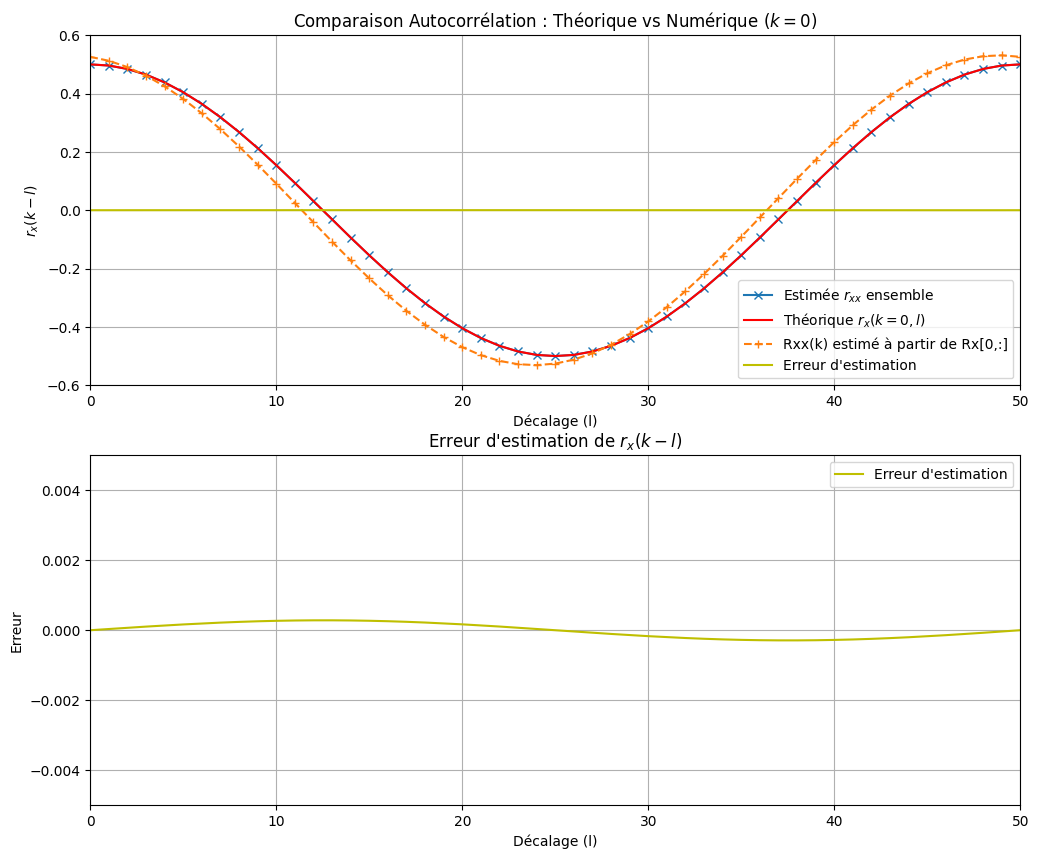

In [6]:
# Autocorrélation théorique : rx(k) = (A²/2) * cos(k * omega0)
k_lags = np.arange(N)
rx_theorique = 0.5 * (A**2) * np.cos(k_lags * omega0)

print(f"Forme de rx_theorique : {rx_theorique.shape}")

# Extraction de l'autocorrélation estimée (lags positifs depuis rxx_ensemble)
rx_estim = rxx_ensemble[N-1:N-1+N]

print(f"Forme de rx_estim : {rx_estim.shape}")

# Calcul de l'erreur d'estimation
erreur = rx_theorique - rx_estim
Eerr = np.sum(erreur**2)
print(f"Erreur quadratique totale : {Eerr}")

plt.figure(figsize=(12, 10))

# Comparaison théorique vs estimée
plt.subplot(2, 1, 1)
plt.plot(k_lags, rx_estim, 'x-', label="Estimée $r_{xx}$ ensemble")
plt.plot(k_lags, rx_theorique, 'r-', label="Théorique $r_x(k=0, l)$")
plt.plot(k_lags[0:N-1], rx_etime_Rx_pos[0:N], marker='+', linestyle='--', label="Rxx(k) estimé à partir de Rx[0,:]")
plt.plot(k_lags, erreur, 'y', label="Erreur d'estimation")
plt.title("Comparaison Autocorrélation : Théorique vs Numérique ($k=0$)")
plt.xlabel("Décalage (l)")
plt.ylabel("$r_x(k-l)$")
plt.axis([0, 50, -0.6, 0.6])
plt.legend()
plt.grid(True)

# Erreur seule
plt.subplot(2, 1, 2)
plt.plot(k_lags, erreur, 'y', label="Erreur d'estimation")
plt.title("Erreur d'estimation de $r_x(k-l)$")
plt.xlabel("Décalage (l)")
plt.ylabel("Erreur")
plt.axis([0, 50, -0.005, 0.005])
plt.legend()
plt.grid(True)

plt.show()

### Analyse des résultats

**Symétrie :** La matrice $R_x$ est symétrique par construction, car $R_x = \frac{1}{N_R} X^T X$ implique $R_x = R_x^T$. Cela est cohérent avec la propriété théorique $r_{xx}(k) = r_{xx}(-k)$.

**Convergence :** Avec $N_R = 100$ réalisations, l'estimation numérique converge bien vers la fonction théorique $\frac{A^2}{2}\cos(2\pi f_0 k)$. Plus $N_R$ est grand, meilleure est l'estimation — c'est la loi des grands nombres appliquée à l'espérance.

**Erreur :** Les fluctuations résiduelles (erreur en jaune) sont dues au nombre fini de réalisations. Leur amplitude reste très faible (ordre de $10^{-3}$), ce qui confirme la qualité de l'estimation pour $N_R = 100$.

## Autocorrélation d'une somme de processus (Exemple 3.3.3)

On considère un processus $y(n)$ somme de $M$ sinusoïdes à phases aléatoires et d'un bruit blanc gaussien $v(n)$ :

$$y(n) = x(n) + v(n) = \left[\sum_{m=1}^M A_m \sin(n\omega_m + \phi_m)\right] + v(n)$$

**Paramètres :**
- $M = 5$ harmoniques
- $\omega_m = \omega_0 / m$ — fréquences harmoniquement décroissantes
- $A_m = A_0 / m$ — amplitudes décroissantes (harmoniques naturelles)
- $\phi_m \sim \mathcal{U}[0, 2\pi]$ — phase aléatoire indépendante pour chaque harmonique et chaque réalisation
- $v(n) \sim \mathcal{N}(0, A_0^2)$ — bruit blanc gaussien d'écart-type $A_0$

> **Propriété théorique :** Puisque $x(n)$ et $v(n)$ sont décorrélés, l'autocorrélation de $y(n)$ est la somme des autocorrélations individuelles :
> $$R_{yy}(k) = R_{xx}(k) + R_{vv}(k) = \sum_{m=1}^M \frac{A_m^2}{2}\cos(\omega_m k) + \sigma^2 \delta(k)$$
> Le bruit blanc contribue uniquement en $k=0$ (pic de Dirac), tandis que chaque sinusoïde contribue un cosinus à sa fréquence propre.

L'objectif est de générer la matrice $yh(n)$ (somme des harmoniques) puis d'y ajouter le bruit $v(n)$ généré avec `randn()`.

### Visualisation de une  réalisation de y(n) :
Il est utile d'afficher une réalisation pour voir l'aspect du signal (mélange de sinusoïdes lentes et de bruit fort).


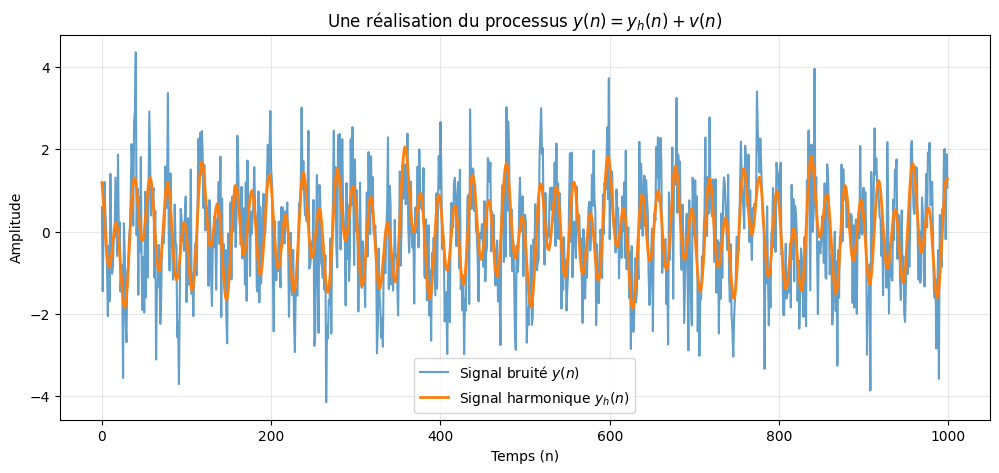

In [7]:
# --- 1. Paramètres ---
A0 = 1.0
f0 = 0.05
omega0 = 2 * np.pi * f0
M = 5
N = 1000
NR = 1000
np.random.seed(42)

# --- 2. Génération du signal harmonique yh(n) ---
n = np.arange(N)
yh = np.zeros((NR, N))  # Convention (NR x N) : Réalisations x Temps

for m in range(1, M + 1):
    Am = A0 / m
    wm = omega0 / m
    phi_m = np.random.uniform(0, 2 * np.pi, (NR, 1))  # (NR, 1) pour broadcasting
    yh += Am * np.sin(wm * n + phi_m)

# --- 3. Génération du bruit blanc v(n) ---
v = A0 * np.random.randn(NR, N)

# --- 4. Signal total y_33(n) ---
y_33 = yh + v

# --- 5. Visualisation d'une réalisation ---
plt.figure(figsize=(12, 5))
plt.plot(n, y_33[0, :], label='Signal bruité $y(n)$', alpha=0.7)
plt.plot(n, yh[0, :], label='Signal harmonique $y_h(n)$', linewidth=2)
plt.title(r"Une réalisation du processus $y(n) = y_h(n) + v(n)$")
plt.xlabel("Temps (n)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Points clés à retenir

**Fréquences $\omega_m$ :** Avec $\omega_m = \omega_0/m$, les harmoniques sont de plus en plus lentes à mesure que $m$ augmente — la composante $m=1$ est la plus rapide, $m=5$ la plus lente.

**Amplitudes $A_m$ :** Avec $A_m = A_0/m$, la puissance de chaque harmonique vaut $A_m^2/2 = A_0^2/(2m^2)$ — les composantes hautes fréquences sont donc énergétiquement négligeables devant la fondamentale.

**Bruit $v(n)$ :** Avec un écart-type $A_0$, la puissance du bruit $\sigma^2 = A_0^2$ est égale à la puissance de la composante fondamentale ($m=1$). Le bruit est donc dominant par rapport aux harmoniques d'ordre supérieur.

**Indépendance des phases :** Chaque $\phi_m$ est tirée indépendamment pour chaque harmonique et chaque réalisation. C'est cette indépendance qui garantit que les autocorrélations des harmoniques s'additionnent sans termes croisés :
$$R_{yy}(k) = \sum_{m=1}^M \frac{A_m^2}{2}\cos(\omega_m k) + A_0^2\,\delta(k)$$

### Calcul des autocorrélations d'ensemble et temporelle de $y(n)$

On cherche à vérifier numériquement que l'autocorrélation d'une somme de processus indépendants est égale à la somme de leurs autocorrélations :

$$R_{yy}(k) = R_{y_h y_h}(k) + R_{vv}(k)$$

Cette égalité repose sur l'**absence de corrélation** entre $y_h(n)$ et $v(n)$ — les termes croisés $\mathbb{E}[y_h(n)v(n+k)]$ sont nuls car les deux processus sont indépendants.

On estime l'autocorrélation de trois façons :
- **Autocorrélation d'ensemble de $y(n)$** — moyenne sur les $N_R$ réalisations via `compute_avg_autocorr`
- **Autocorrélation d'ensemble de $y_h(n)$** — contribution harmonique seule
- **Autocorrélation d'ensemble de $v(n)$** — contribution du bruit seule (pic en $k=0$ uniquement)

> Si les résultats sont cohérents, on doit observer que la somme $R_{y_h y_h}(k) + R_{vv}(k)$ coïncide avec $R_{yy}(k)$ — ce qui constitue une vérification expérimentale de la linéarité de l'espérance.

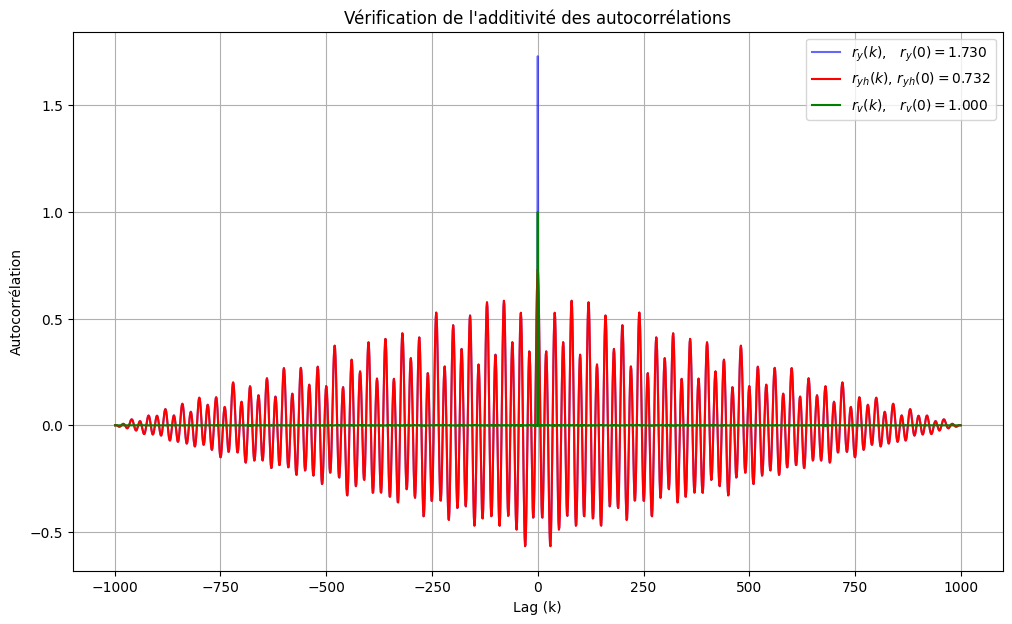

In [10]:
def compute_avg_autocorr(matrix):
    """
    Calcule la corrélation moyenne sur toutes les réalisations.
    Attend une matrice de forme (NR, N).
    """
    n_real, n_samp = matrix.shape
    corr_sum = np.zeros(2 * n_samp - 1)
    for i in range(n_real):
        corr_sum += signal.correlate(matrix[i, :], matrix[i, :], mode='full') / n_samp
    return corr_sum / n_real

# --- 1. Processus harmonique yh ---
n = np.arange(N)
yh = np.zeros((NR, N))
for m in range(1, M + 1):
    phi_m = np.random.uniform(0, 2 * np.pi, NR)
    yh += (A0/m) * np.sin(2 * np.pi * (f0/m) * n + phi_m[:, None])

# --- 2. Bruit blanc gaussien v ---
v = A0 * np.random.randn(NR, N)

# --- 3. Processus total y ---
y_33 = yh + v

# --- 4. Calcul des autocorrélations ---
ryh_avg = compute_avg_autocorr(yh)
rvv_avg = compute_avg_autocorr(v)
ryy_avg = compute_avg_autocorr(y_33)
lags_full = np.arange(-(N - 1), N)

# --- 5. Visualisation ---
plt.figure(figsize=(12, 7))
plt.plot(lags_full, ryy_avg, 'b', alpha=0.6, label=f'$r_y(k)$,   $r_y(0) = {ryy_avg[N-1]:.3f}$')
plt.plot(lags_full, ryh_avg, 'r',             label=f'$r_{{yh}}(k)$, $r_{{yh}}(0) = {ryh_avg[N-1]:.3f}$')
plt.plot(lags_full, rvv_avg, 'g',             label=f'$r_v(k)$,   $r_v(0) = {rvv_avg[N-1]:.3f}$')
plt.title("Vérification de l'additivité des autocorrélations")
plt.xlabel("Lag (k)")
plt.ylabel("Autocorrélation")
plt.legend()
plt.grid(True)
plt.show()

### Analyse des résultats

**Comportement de $r_v(k)$ :** L'autocorrélation du bruit blanc gaussien est un pic de Dirac : maximale en $k=0$ avec $r_v(0) = \sigma^2 = A_0^2 = 1$, et quasi-nulle pour tout $k \neq 0$. C'est la définition même du bruit blanc — ses échantillons sont décorrélés entre eux.

**Comportement de $r_{y_h}(k)$ :** L'autocorrélation du signal harmonique présente une structure périodique, reflet des $M$ sinusoïdes superposées. En $k=0$, elle vaut la puissance totale du signal harmonique :

$$r_{y_h}(0) = \sum_{m=1}^M \frac{A_m^2}{2} = \frac{A_0^2}{2} \sum_{m=1}^M \frac{1}{m^2} \approx 0.7318$$

Pour $k \neq 0$, les oscillations reflètent les différentes fréquences $\omega_m$ présentes dans le signal.

**Comportement de $r_y(k)$ :** L'autocorrélation totale est la somme des deux précédentes, grâce à l'indépendance de $y_h$ et $v$ :

$$r_y(0) = r_{y_h}(0) + r_v(0) \approx 0.7318 + 1 = 1.7318$$

Pour $k \neq 0$, $r_y(k)$ conserve la structure périodique de $r_{y_h}(k)$, le bruit ne contribuant qu'en $k=0$.

> **Erreur résiduelle :** La légère différence entre les valeurs numériques et théoriques est due au nombre fini de réalisations ($N_R = 1000$). Par la loi des grands nombres, cette erreur tend vers zéro quand $N_R \to \infty$.


## Calcul de la densité spectrale de puissance (DSP)

La DSP est obtenue par transformée de Fourier de l'autocorrélation, selon le **théorème de Wiener-Khinchin** :

$$S_{yy}(f) = \mathcal{F}\{R_{yy}(k)\} = \sum_{k=-\infty}^{+\infty} R_{yy}(k)\, e^{-j2\pi fk}$$

**Pour notre processus $y(n)$, la DSP théorique est :**
$$S_{yy}(f) = \underbrace{\sum_{m=1}^M \frac{A_m^2}{4}\left[\delta(f - f_m) + \delta(f + f_m)\right]}_{\text{raies harmoniques}} + \underbrace{\sigma^2}_{\text{plancher de bruit}}$$

**Échelle logarithmique (dB) :** On exprime la DSP en décibels pour visualiser simultanément les raies harmoniques (forte puissance) et le plancher de bruit (très faible puissance) qui seraient sinon invisibles sur une échelle linéaire :

$$S_{dB}(f) = 10\log_{10}(S_{yy}(f))$$

> **Ce que l'on attend :** $M = 5$ raies spectrales aux fréquences $f_m = f_0/m$, avec des amplitudes décroissantes en $1/m^2$, au-dessus d'un plancher de bruit blanc constant.

<>:36: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:36: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_124114/3601357866.py:36: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax2.plot(freqs, S_theory_dB, 'r--', alpha=0.8, label='Somme théorique $10\log_{10}(S_{yh} + S_v)$')


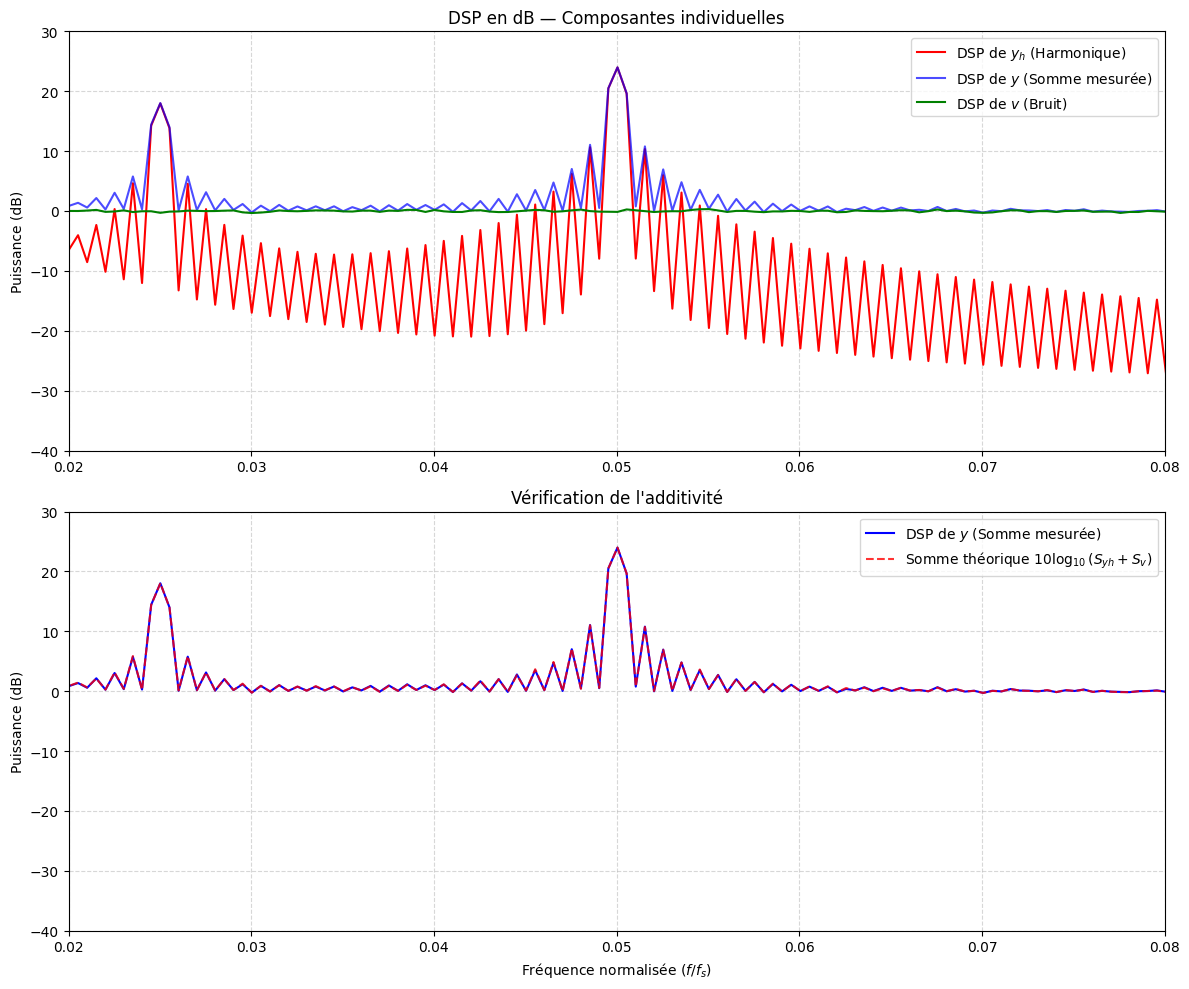

In [11]:
# --- 1. Calcul des DSP via FFT (théorème de Wiener-Khinchin) ---
def get_psd(r_signal):
    S_linear = np.abs(np.fft.fftshift(np.fft.fft(np.fft.ifftshift(r_signal))))
    return S_linear

Syh = get_psd(ryh_avg)
Sv  = get_psd(rvv_avg)
Sy  = get_psd(ryy_avg)

# Axe fréquentiel normalisé (longueur = 2*N - 1)
freqs = np.linspace(-0.5, 0.5, len(lags_full))

# --- 2. Conversion en décibels ---
# epsilon = 1e-12 pour éviter log(0)
Syh_dB        = 10 * np.log10(Syh + 1e-12)
Sv_dB         = 10 * np.log10(Sv  + 1e-12)
Sy_dB         = 10 * np.log10(Sy  + 1e-12)
S_theory_dB   = 10 * np.log10(Syh + Sv + 1e-12)

# --- 3. Visualisation ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Composantes individuelles
ax1.plot(freqs, Syh_dB, 'r',         label='DSP de $y_h$ (Harmonique)')
ax1.plot(freqs, Sy_dB,  'b', alpha=0.7, label='DSP de $y$ (Somme mesurée)')
ax1.plot(freqs, Sv_dB,  'g',         label='DSP de $v$ (Bruit)')
ax1.set_title("DSP en dB — Composantes individuelles")
ax1.set_ylabel("Puissance (dB)")
ax1.set_ylim([-40, 30])
ax1.set_xlim([0.02, 0.08])
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# Vérification de l'additivité
ax2.plot(freqs, Sy_dB,       'b',      label='DSP de $y$ (Somme mesurée)')
ax2.plot(freqs, S_theory_dB, 'r--', alpha=0.8, label='Somme théorique $10\log_{10}(S_{yh} + S_v)$')
ax2.set_title("Vérification de l'additivité")
ax2.set_xlabel("Fréquence normalisée ($f/f_s$)")
ax2.set_ylabel("Puissance (dB)")
ax2.set_ylim([-40, 30])
ax2.set_xlim([0.02, 0.08])
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

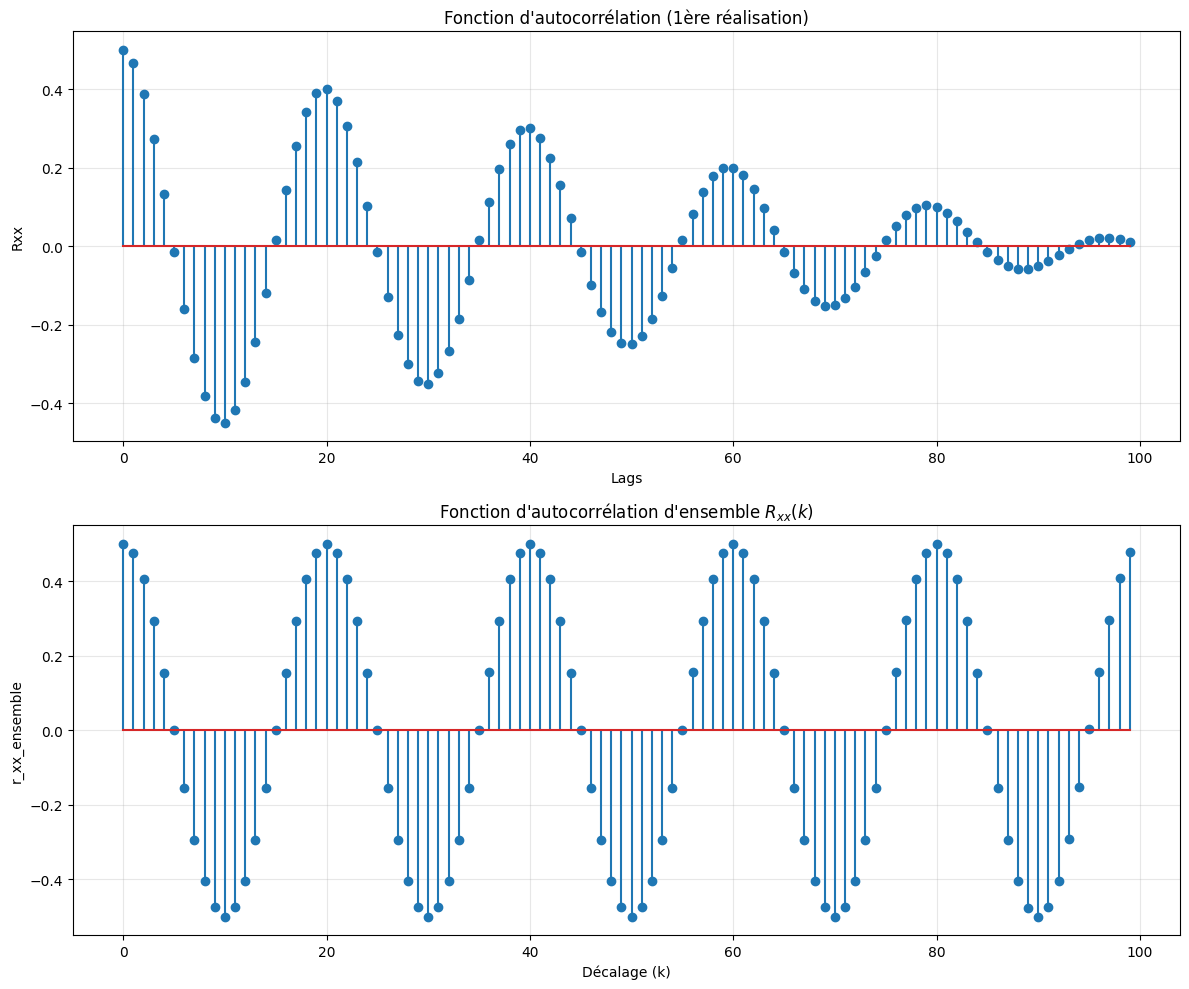

In [12]:
# --- 1. Parameters ---
A = 1.0
f0 = 0.05
N = 100
NR = 1000
np.random.seed(0)

# --- 2. Generation ---
n = np.arange(N)
phi = np.random.uniform(0, 2 * np.pi, NR)
# X shape: (N, NR) -> (Time, Realizations)
X = A * np.cos(2 * np.pi * f0 * n[:, None] + phi)

# --- 3. Temporal Autocorrelation (1st realization) ---
# We take the first column of X
x1 = X[:, 0]
# Calculate correlation and take the second half (lags 0 to N-1)
rxx_temp = signal.correlate(x1, x1, mode='full')[N-1:] / N

# --- 4. Ensemble Autocorrelation (Average of diagonals) ---
Rx_matrix = (1 / NR) * (X @ X.T)
lags_positive = np.arange(N)
rxx_ens = np.zeros(N)

for k in lags_positive:
    # We take the mean of the k-th diagonal
    rxx_ens[k] = np.mean(np.diag(Rx_matrix, k))

# --- 5. Plotting (Reproducing your images) ---
plt.figure(figsize=(12, 10))

# Top Plot: Temporal Autocorrelation
plt.subplot(2, 1, 1)
plt.stem(lags_positive, rxx_temp)
plt.title("Fonction d'autocorrélation (1ère réalisation)")
plt.xlabel("Lags")
plt.ylabel("Rxx")
plt.grid(True, alpha=0.3)

# Bottom Plot: Ensemble Autocorrelation
plt.subplot(2, 1, 2)
plt.stem(lags_positive, rxx_ens)
plt.title(r"Fonction d'autocorrélation d'ensemble $R_{xx}(k)$")
plt.xlabel("Décalage (k)")
plt.ylabel("r_xx_ensemble")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()